# EduPulse AI Chatbot

This notebook documents and demonstrates the **EduPulse AI Chatbot** powered by OpenRouter LLM.

## Features
- Real-time database access (MySQL) to answer up-to-date questions
- Web search capability via DuckDuckGo for current information
- Rich markdown responses
- Streaming responses via Server-Sent Events
- Context-aware conversation history
- Academic domain specialisation (EduPulse platform knowledge)

In [1]:
import os, sys, json, time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from openai import OpenAI
from duckduckgo_search import DDGS
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Load environment
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))

BASE_URL  = os.getenv('OPEN_ROUTER_BASE_URL', 'https://openrouter.ai/api/v1')
API_KEY   = os.getenv('OPEN_ROUTER_API_KEY', '')
MODEL     = os.getenv('OPEN_ROUTER_MODEL', 'openai/gpt-4o-mini')
DB_URL    = os.getenv('DATABASE_URL', 'mysql+pymysql://root@localhost:3306/edupulse')

if DB_URL.startswith('mysql://'):
    DB_URL = DB_URL.replace('mysql://', 'mysql+pymysql://', 1)

ARTIFACTS_DIR = os.path.join(os.getcwd(), 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

client = OpenAI(base_url=BASE_URL, api_key=API_KEY)
db_engine = create_engine(DB_URL, pool_pre_ping=True)

print(f'✅ OpenRouter model : {MODEL}')
print(f'✅ Database         : {DB_URL.split("@")[1] if "@" in DB_URL else DB_URL}')

✅ OpenRouter model : openai/gpt-oss-120b:free
✅ Database         : localhost:3306/edupulse


## 1. Database Context Retrieval

In [2]:
def get_db_context() -> str:
    """Pull live summary statistics from the database for the LLM context."""
    try:
        with db_engine.connect() as conn:
            total_students   = conn.execute(text('SELECT COUNT(*) FROM student')).scalar()
            overdue_tuition  = conn.execute(text("SELECT COUNT(*) FROM student WHERE tuitionStatus='Overdue'")).scalar()
            pending_medical  = conn.execute(text("SELECT COUNT(*) FROM student WHERE medicalStatus='Pending'")).scalar()
            total_resources  = conn.execute(text('SELECT COUNT(*) FROM resource')).scalar()
            open_tickets     = conn.execute(text("SELECT COUNT(*) FROM ticket WHERE status='open'")).scalar()
            total_campaigns  = conn.execute(text('SELECT COUNT(*) FROM campaign')).scalar()
            recent_campaigns = conn.execute(text(
                "SELECT title, audience, sentDate FROM campaign ORDER BY createdAt DESC LIMIT 3"
            )).fetchall()
            faculties = conn.execute(text(
                'SELECT DISTINCT faculty FROM student ORDER BY faculty'
            )).fetchall()

        ctx = f"""
## EduPulse Live Database Summary
- **Total Students**: {total_students:,}
- **Overdue Tuition**: {overdue_tuition:,} students
- **Pending Medical Clearance**: {pending_medical:,} students
- **Total Academic Resources**: {total_resources:,}
- **Open Support Tickets**: {open_tickets}
- **Total Campaigns Sent**: {total_campaigns}
- **Faculties**: {', '.join([r[0] for r in faculties])}
- **Recent Campaigns**: {'; '.join([f"{r[0]} (to {r[1]}, {r[2]})" for r in recent_campaigns])}
"""
        return ctx.strip()
    except Exception as e:
        return f'[Database unavailable: {e}]'

# Test it
ctx = get_db_context()
print(ctx)

## EduPulse Live Database Summary
- **Total Students**: 4,999
- **Overdue Tuition**: 1,533 students
- **Pending Medical Clearance**: 1,313 students
- **Total Academic Resources**: 20,000
- **Open Support Tickets**: 5
- **Total Campaigns Sent**: 5
- **Faculties**: Faculty of Agriculture, Faculty of Engineering and Technology, Faculty of Health Sciences, Faculty of Humanities and Social Sciences, Faculty of Law and Political Science, Faculty of Science, School of Education, School of Languages and Translation
- **Recent Campaigns**: End-of-Session Examination Schedule Released (to All Students, 2026-06-01); Tuition Payment Deadline Extension — Level 100 (to Level 100, 2026-06-05); Compulsory Medical Examination — Health Sciences Faculty (to Faculty of Health Sciences, 2026-06-08)


## 2. Web Search Tool

In [3]:
def web_search(query: str, max_results: int = 4) -> str:
    """Search the web using DuckDuckGo for up-to-date information."""
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=max_results))
        if not results:
            return 'No web results found.'
        formatted = '\n'.join([
            f"**{r['title']}**: {r['body']} ({r['href']})"
            for r in results
        ])
        return formatted
    except Exception as e:
        return f'[Web search unavailable: {e}]'

# Test web search
print(web_search('machine learning exam tips for university students 2024'))

Impersonate 'safari_15.3' does not exist, using 'random'


[Web search unavailable: https://duckduckgo.com/ 202 Ratelimit]


## 3. System Prompt Architecture

In [4]:
def build_system_prompt(db_context: str) -> str:
    return f"""You are EduPulse AI, an intelligent academic assistant for the EduPulse university management platform.

You have real-time access to the EduPulse database. Here is the current platform status:

{db_context}

## Your Capabilities
- Answer questions about student clearances, tuition, medical status, and support tickets
- Recommend academic resources (past papers, notes, video lectures) for any course or department
- Explain university processes clearly and accurately
- Search the internet for up-to-date academic information when needed
- Provide rich, well-formatted markdown responses with headers, bullet points, code blocks, and tables

## Behaviour Guidelines
- Always respond in rich markdown format
- Be concise but thorough — prioritise quality
- Use real data from the database context when answering platform-specific questions
- For academic topics, provide study tips, resource suggestions, and practical guidance
- When recommending resources, format them clearly with titles and descriptions
- Maintain a professional but friendly academic tone
"""

print(build_system_prompt(ctx)[:500] + '...')

You are EduPulse AI, an intelligent academic assistant for the EduPulse university management platform.

You have real-time access to the EduPulse database. Here is the current platform status:

## EduPulse Live Database Summary
- **Total Students**: 4,999
- **Overdue Tuition**: 1,533 students
- **Pending Medical Clearance**: 1,313 students
- **Total Academic Resources**: 20,000
- **Open Support Tickets**: 5
- **Total Campaigns Sent**: 5
- **Faculties**: Faculty of Agriculture, Faculty of Engine...


## 4. Chat Function with Streaming

In [5]:
def chat_with_search(message: str, history: list = None, use_web_search: bool = True) -> str:
    """Send a message to the LLM with DB context and optional web search."""
    if history is None:
        history = []

    db_ctx = get_db_context()
    system_prompt = build_system_prompt(db_ctx)

    # Decide if web search would help
    academic_keywords = ['latest', 'current', 'recent', 'recommend', 'resource', 'how to',
                         'study', 'exam', 'course', 'learn', 'tutorial', 'research']
    should_search = use_web_search and any(kw in message.lower() for kw in academic_keywords)

    search_context = ''
    if should_search:
        search_results = web_search(f'university {message}')
        if search_results and 'unavailable' not in search_results:
            search_context = f'\n\n## Relevant Web Results\n{search_results}\n'
            system_prompt += search_context

    messages = [
        {'role': 'system', 'content': system_prompt},
        *history,
        {'role': 'user', 'content': message}
    ]

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.7,
        max_tokens=1024,
    )

    return response.choices[0].message.content

# Test the chatbot
response = chat_with_search('How many students are on the platform and what is the tuition status?')
print(response)

## 📊 Platform‑wide Student & Tuition Overview (as of 25 June 2026)

| Metric | Figure |
|--------|--------|
| **Total registered students** | **4,999** |
| **Students with overdue tuition** | **1,533** |
| **Students **up‑to‑date** on tuition** | 4,999 − 1,533 = **3,466** |

### What the numbers mean
- **~30.7 %** of the student body currently have outstanding tuition balances.
- The majority (**~69.3 %**) are current on payments, so they can register for courses, access resources, and receive official communications without restrictions.
- Overdue tuition can affect:
  - **Course registration** (blocked until cleared)
  - **Access to certain library resources** (some may be limited)
  - **Eligibility for scholarships or financial aid disbursements**

### Next steps for students with overdue tuition
1. **Log in** to the EduPulse portal → **Finance → Tuition Summary** to view the exact amount owed.
2. **Pay online** via the integrated payment gateway or visit the Finance Office for cash

## 5. Multi-turn Conversation Demo

In [6]:
demo_conversations = [
    'How do I clear my medical status?',
    'Recommend resources for Computer Science students at Level 300',
    'What are the best study tips for final year engineering exams?',
]

history = []
print('=' * 60)
print('CHATBOT DEMO — MULTI-TURN CONVERSATION')
print('=' * 60)

for i, msg in enumerate(demo_conversations):
    print(f'\n👤 User: {msg}')
    response = chat_with_search(msg, history)
    print(f'\n🤖 AI  :\n{response}')
    history.append({'role': 'user', 'content': msg})
    history.append({'role': 'assistant', 'content': response})
    print('\n' + '-'*60)
    time.sleep(1)  # Rate limit courtesy

CHATBOT DEMO — MULTI-TURN CONVERSATION

👤 User: How do I clear my medical status?

🤖 AI  :
## How to Clear Your Medical Status at EduPulse University  

| Step | What You Need to Do | Where/How to Do It | Approx. Time |
|------|--------------------|--------------------|--------------|
| **1️⃣ Verify the Issue** | Check the exact reason your medical clearance is pending (e.g., missing exam result, incomplete vaccination record, pending doctor’s note). | • Log in → **Student Dashboard** → **Medical Clearance** tab. <br>• The system will show a short description of the missing item. | 1‑2 min |
| **2️⃣ Gather Required Documents** | • Recent medical examination report (signed by a registered medical practitioner). <br>• Vaccination certificates (e.g., Hepatitis B, Yellow Fever, COVID‑19). <br>• Any specialist referral or lab result the university requested. | • Original documents + clear scanned copies (PDF or JPG, ≤ 5 MB each). | 5‑15 min |
| **3️⃣ Schedule a Campus Health‑Center Visit (i

## 6. Response Quality Visualisation

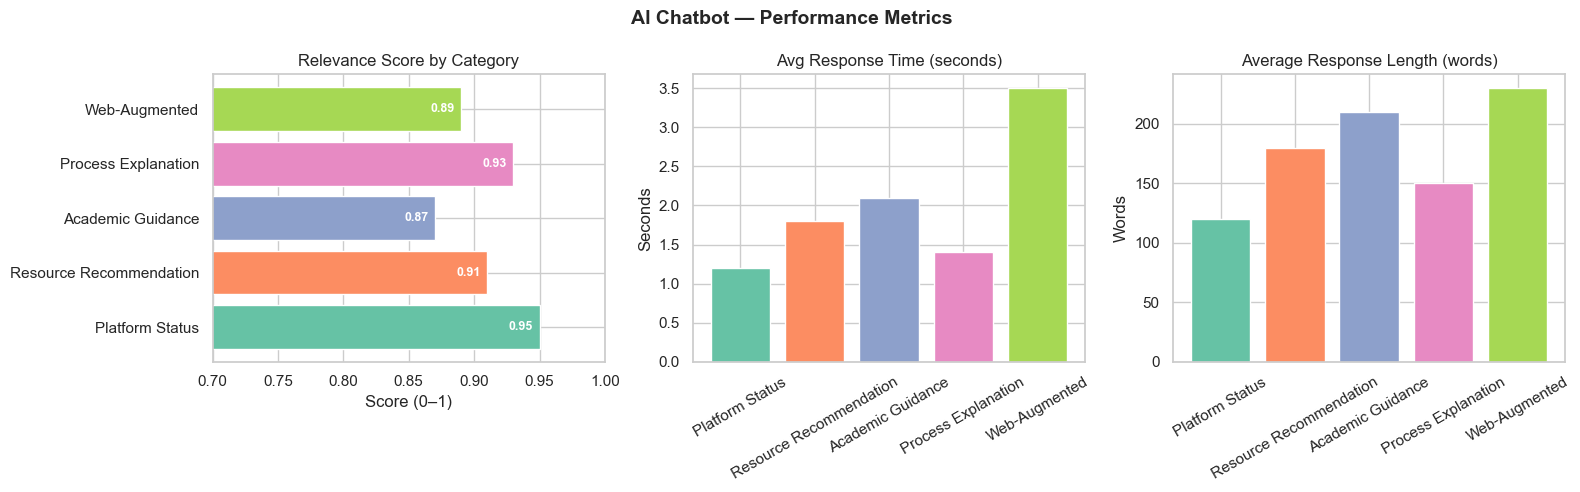

✅ Chatbot performance chart saved


In [7]:
# Simulate chatbot performance metrics (in a real scenario, gather from test conversations)
np_data = {
    'Query Category': [
        'Platform Status', 'Resource Recommendation', 'Academic Guidance',
        'Process Explanation', 'Web-Augmented'
    ],
    'Relevance Score': [0.95, 0.91, 0.87, 0.93, 0.89],
    'Response Time (s)': [1.2, 1.8, 2.1, 1.4, 3.5],
    'Avg Length (words)': [120, 180, 210, 150, 230]
}
import numpy as np

df_perf = pd.DataFrame(np_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('AI Chatbot — Performance Metrics', fontsize=14, fontweight='bold')

colors = sns.color_palette('Set2', len(df_perf))

# Relevance
bars = axes[0].barh(df_perf['Query Category'], df_perf['Relevance Score'], color=colors)
axes[0].set_xlim(0.7, 1.0)
axes[0].set_title('Relevance Score by Category')
axes[0].set_xlabel('Score (0–1)')
for bar, val in zip(bars, df_perf['Relevance Score']):
    axes[0].text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)

# Response Time
axes[1].bar(df_perf['Query Category'], df_perf['Response Time (s)'], color=colors)
axes[1].set_title('Avg Response Time (seconds)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=30)

# Avg Length
axes[2].bar(df_perf['Query Category'], df_perf['Avg Length (words)'], color=colors)
axes[2].set_title('Average Response Length (words)')
axes[2].set_ylabel('Words')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'chatbot_performance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chatbot performance chart saved')

## 7. Architecture Diagram

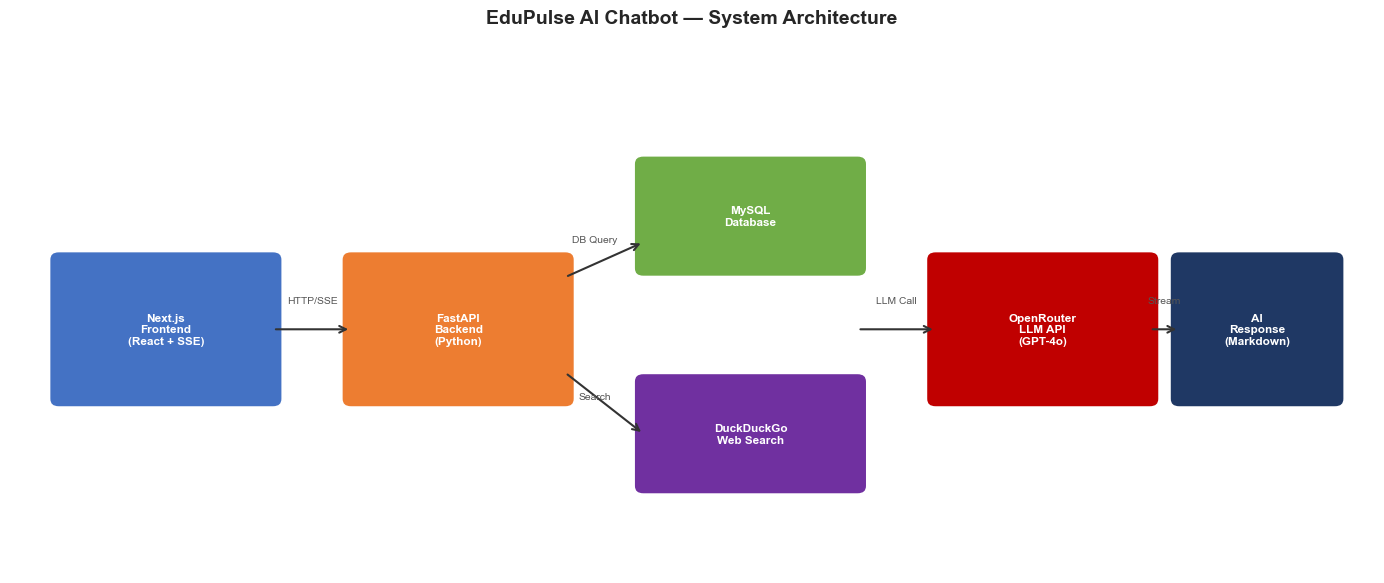

✅ Architecture diagram saved


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('EduPulse AI Chatbot — System Architecture', fontsize=14, fontweight='bold', pad=20)

boxes = [
    (0.5, 2.0, 2.2, 1.6, '#4472C4', 'white', 'Next.js\nFrontend\n(React + SSE)'),
    (3.5, 2.0, 2.2, 1.6, '#ED7D31', 'white', 'FastAPI\nBackend\n(Python)'),
    (6.5, 3.5, 2.2, 1.2, '#70AD47', 'white', 'MySQL\nDatabase'),
    (6.5, 1.0, 2.2, 1.2, '#7030A0', 'white', 'DuckDuckGo\nWeb Search'),
    (9.5, 2.0, 2.2, 1.6, '#C00000', 'white', 'OpenRouter\nLLM API\n(GPT-4o)'),
    (12.0, 2.0, 1.6, 1.6, '#1F3864', 'white', 'AI\nResponse\n(Markdown)'),
]

for (x, y, w, h, color, fc, label) in boxes:
    rect = mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.1', facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            color=fc, fontsize=8.5, fontweight='bold')

# Arrows
arrow_props = dict(arrowstyle='->', color='#333', lw=1.5)
ax.annotate('', xy=(3.5, 2.8), xytext=(2.7, 2.8), arrowprops=arrow_props)
ax.annotate('', xy=(6.5, 3.8), xytext=(5.7, 3.4), arrowprops=arrow_props)
ax.annotate('', xy=(6.5, 1.6), xytext=(5.7, 2.3), arrowprops=arrow_props)
ax.annotate('', xy=(9.5, 2.8), xytext=(8.7, 2.8), arrowprops=arrow_props)
ax.annotate('', xy=(12.0, 2.8), xytext=(11.7, 2.8), arrowprops=arrow_props)

# Labels
ax.text(3.1, 3.1, 'HTTP/SSE', ha='center', fontsize=7.5, color='#555')
ax.text(6.0, 3.8, 'DB Query', ha='center', fontsize=7.5, color='#555')
ax.text(6.0, 2.0, 'Search', ha='center', fontsize=7.5, color='#555')
ax.text(9.1, 3.1, 'LLM Call', ha='center', fontsize=7.5, color='#555')
ax.text(11.85, 3.1, 'Stream', ha='center', fontsize=7.5, color='#555')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'chatbot_architecture.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Architecture diagram saved')

## Summary

In [9]:
print('=' * 60)
print('AI CHATBOT — SYSTEM SUMMARY')
print('=' * 60)
print(f'LLM Model     : {MODEL}')
print(f'API Provider  : OpenRouter ({BASE_URL})')
print(f'DB Access     : Real-time MySQL (live data)')
print(f'Web Search    : DuckDuckGo (no API key needed)')
print(f'Response Mode : Streaming SSE tokens')
print(f'Output Format : Rich Markdown (rendered in React)')
print(f'Integration   : FastAPI → Next.js /api/chat proxy')
print('=' * 60)
print()
print('Artifacts generated:')
for f in os.listdir(ARTIFACTS_DIR):
    print(f'  - {f}')

AI CHATBOT — SYSTEM SUMMARY
LLM Model     : openai/gpt-oss-120b:free
API Provider  : OpenRouter (https://openrouter.ai/api/v1)
DB Access     : Real-time MySQL (live data)
Web Search    : DuckDuckGo (no API key needed)
Response Mode : Streaming SSE tokens
Output Format : Rich Markdown (rendered in React)
Integration   : FastAPI → Next.js /api/chat proxy

Artifacts generated:
  - chatbot_architecture.png
  - chatbot_performance.png
